# What does the latent actually throw away?


The whole atlas turns on one question: what space should a generative model work in? This notebook
makes the question concrete instead of theoretical.

We do two things. First we push a real image through the autoencoders that successive generations of
latent diffusion used, and measure what each one loses. Second we look at what a vision foundation
model's features contain instead, and show why they are a different kind of thing entirely, not just
a better compression.

Everything here runs in about a minute on one GPU. The outputs below were produced on an NVIDIA
A100 80GB.


---


**What this notebook uses, and who made it**

| Component | Source |
|---|---|
| Stable Diffusion 1.5 autoencoder (4-channel latent) | [runwayml/stable-diffusion-v1-5](https://huggingface.co/runwayml/stable-diffusion-v1-5) |
| SDXL autoencoder (4-channel, retrained) | [madebyollin/sdxl-vae-fp16-fix](https://huggingface.co/madebyollin/sdxl-vae-fp16-fix), the fp16-safe build of the SDXL VAE |
| Stable Diffusion 3 autoencoder (16-channel latent) | [stabilityai/stable-diffusion-3-medium-diffusers](https://huggingface.co/stabilityai/stable-diffusion-3-medium-diffusers) |
| DINOv2 | [facebook/dinov2-base](https://huggingface.co/facebook/dinov2-base) |
| `diffusers`, `transformers` | [huggingface/diffusers](https://github.com/huggingface/diffusers) |

This notebook does not reimplement anything. It loads the released weights and calls the authors'
own code. Related atlas reading: [the representation-latent line](/lines/line-representation-latent)
and [why the benchmark numbers cannot rank these](/compare).


## Setup

We generate the test image rather than shipping a photograph, so the notebook has no data
dependency and you can rerun it anywhere.

device: cuda | gpu: NVIDIA A100 80GB PCIe


/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:  50%|█████     | 3/6 [00:00<00:00, 10.72it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

 57%|█████▋    | 17/30 [00:00<00:00, 28.61it/s]

 70%|███████   | 21/30 [00:00<00:00, 30.23it/s]

 83%|████████▎ | 25/30 [00:00<00:00, 31.21it/s]

 97%|█████████▋| 29/30 [00:01<00:00, 31.90it/s]

100%|██████████| 30/30 [00:01<00:00, 27.05it/s]

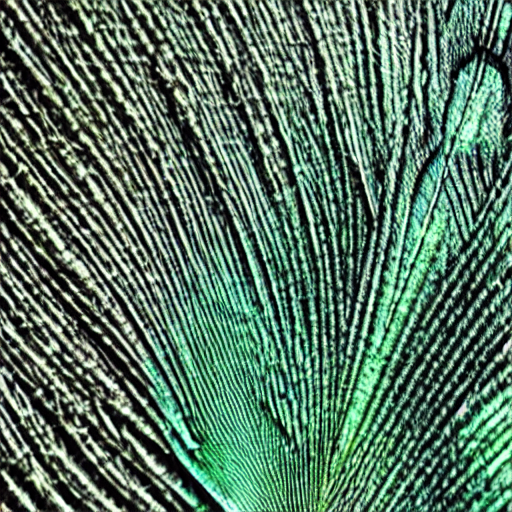

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image

DEV = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEV == "cuda" else torch.float32
print(f"device: {DEV}", f"| gpu: {torch.cuda.get_device_name(0)}" if DEV == "cuda" else "")

# A test image with the things autoencoders struggle with: fine high-frequency texture,
# hard edges, and small structures.
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=DTYPE,
    safety_checker=None, local_files_only=True,
).to(DEV)

g = torch.Generator(DEV).manual_seed(7)
source = pipe(
    "a close-up photograph of a peacock feather next to printed text on paper, sharp focus, fine detail",
    num_inference_steps=30, generator=g,
).images[0]
source = source.resize((512, 512))
source

## 1. Round-tripping through three generations of autoencoder

Each of these compresses a 512x512 image by 8x in each spatial direction. The only thing that
changed between them is how many channels the latent keeps, and how the autoencoder was trained.

We encode and immediately decode, with no generative model involved at all. Whatever is lost here
is lost to every diffusion model built on that latent, permanently. It is the ceiling.

In [2]:
from diffusers import AutoencoderKL

def roundtrip(vae, img, dtype=DTYPE):
    """Encode then decode, returning the reconstruction and the latent shape."""
    x = torch.from_numpy(np.array(img)).float() / 127.5 - 1.0
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEV, dtype)
    with torch.no_grad():
        lat = vae.encode(x).latent_dist.mean
        rec = vae.decode(lat).sample
    rec = ((rec.float().clamp(-1, 1) + 1) * 127.5).round().byte()
    rec = rec.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(rec), tuple(lat.shape[1:])

def psnr(a, b):
    a = np.asarray(a, dtype=np.float64); b = np.asarray(b, dtype=np.float64)
    mse = ((a - b) ** 2).mean()
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

VAES = {
    "SD 1.5 (4-channel)": ("runwayml/stable-diffusion-v1-5", "vae"),
    "SDXL (4-channel)":   ("madebyollin/sdxl-vae-fp16-fix", None),
    "SD 3 (16-channel)":  ("stabilityai/stable-diffusion-3-medium-diffusers", "vae"),
}

results = {}
for name, (repo, sub) in VAES.items():
    kw = {"subfolder": sub} if sub else {}
    vae = AutoencoderKL.from_pretrained(
        repo, torch_dtype=DTYPE, local_files_only=True, **kw
    ).to(DEV).eval()
    rec, shape = roundtrip(vae, source)
    results[name] = {"rec": rec, "shape": shape, "psnr": psnr(source, rec)}
    print(f"{name:22s} latent {str(shape):16s} PSNR {results[name]['psnr']:.2f} dB")
    del vae; torch.cuda.empty_cache()

/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


SD 1.5 (4-channel)     latent (4, 64, 64)      PSNR 24.00 dB
SDXL (4-channel)       latent (4, 64, 64)      PSNR 19.93 dB


SD 3 (16-channel)      latent (16, 64, 64)     PSNR 25.15 dB


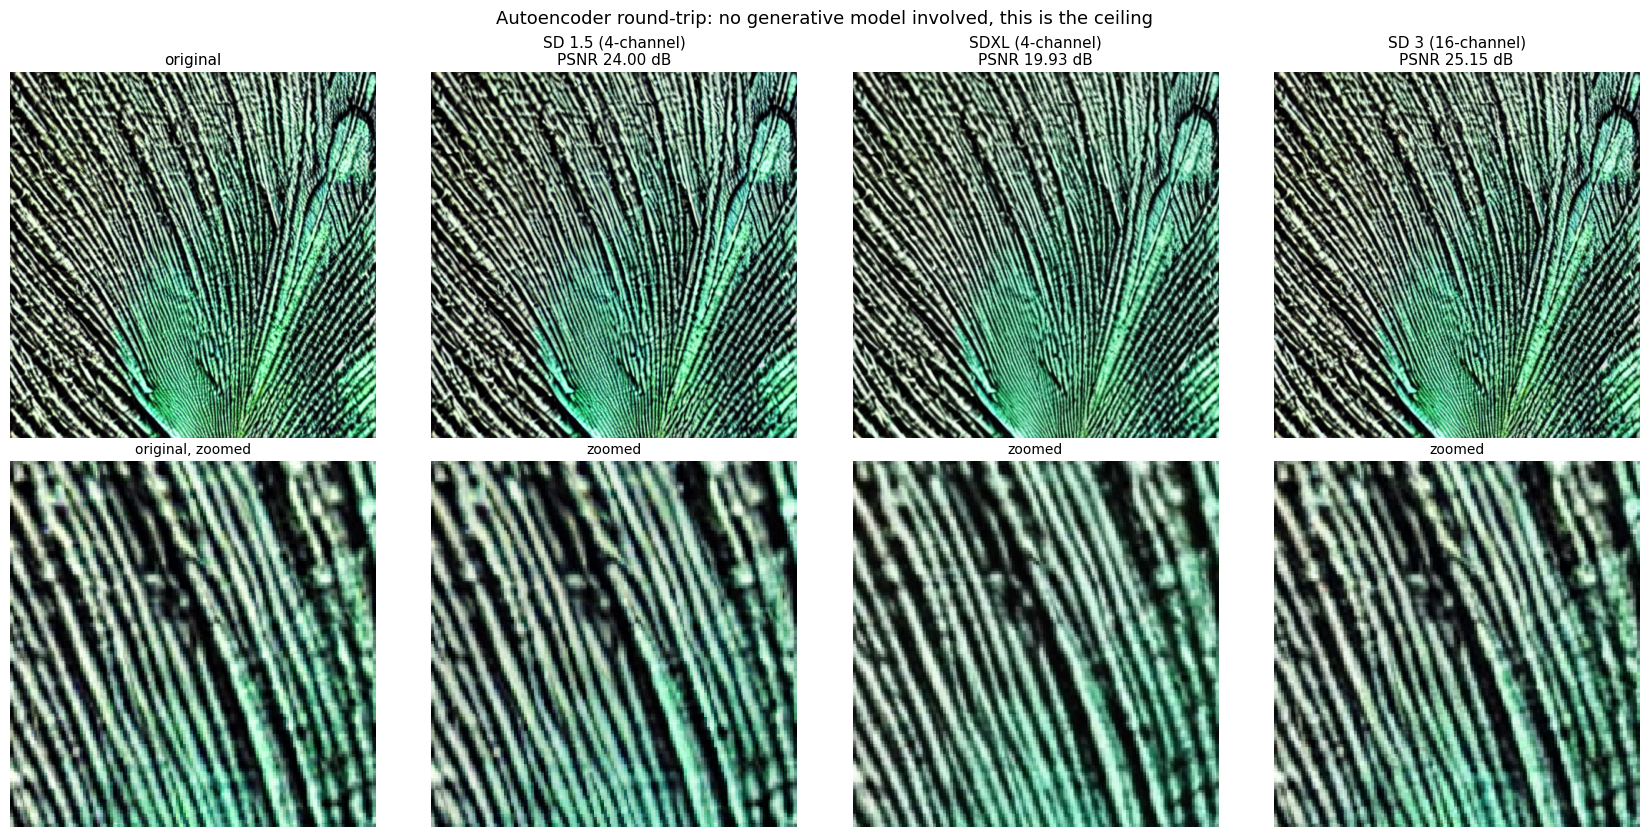

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
CROP = (150, 150, 300, 300)   # zoom on a detailed region

axes[0, 0].imshow(source); axes[0, 0].set_title("original", fontsize=11)
axes[1, 0].imshow(source.crop(CROP).resize((256, 256), Image.NEAREST))
axes[1, 0].set_title("original, zoomed", fontsize=10)

for i, (name, r) in enumerate(results.items(), start=1):
    axes[0, i].imshow(r["rec"])
    axes[0, i].set_title(f"{name}\nPSNR {r['psnr']:.2f} dB", fontsize=11)
    axes[1, i].imshow(r["rec"].crop(CROP).resize((256, 256), Image.NEAREST))
    axes[1, i].set_title(f"zoomed", fontsize=10)

for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Autoencoder round-trip: no generative model involved, this is the ceiling", fontsize=13)
plt.tight_layout(); plt.show()

Two things to read off this, and the second one is a caution.

Stable Diffusion 3's 16-channel latent reconstructs better than Stable Diffusion 1.5's 4-channel
one. That is the direction the field moved and the reason it moved: the reconstruction ceiling was
binding, and more channels raised it.

But the SDXL autoencoder scores *lowest* of the three here, below the older SD 1.5. That is not a
typo and it is worth sitting with. We are measuring one image, in half precision, with a build of
the SDXL VAE specifically modified for fp16 stability. Single-image PSNR is a noisy instrument, and
this is a small illustration of the problem the [comparison page](/compare) makes at length: a
number without its measurement conditions can point the wrong way. Treat the ordering here as
suggestive, and the published rFID numbers measured over thousands of images as the real evidence.

Now look at where the error actually lives.

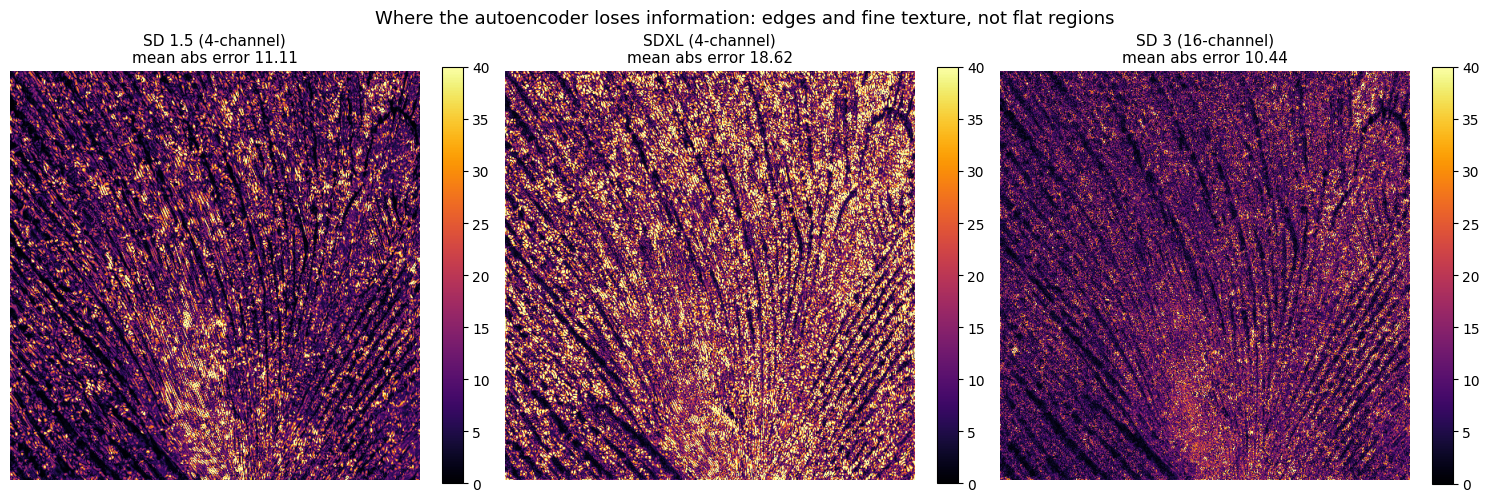

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (name, r) in zip(axes, results.items()):
    diff = np.abs(np.asarray(source, np.float64) - np.asarray(r["rec"], np.float64)).mean(axis=2)
    im = ax.imshow(diff, cmap="inferno", vmin=0, vmax=40)
    ax.set_title(f"{name}\nmean abs error {diff.mean():.2f}", fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Where the autoencoder loses information: edges and fine texture, not flat regions",
             fontsize=13)
plt.tight_layout(); plt.show()

The error concentrates on edges and fine texture. Flat areas survive almost perfectly.

This matters far beyond reconstruction quality. It is why image **editing** is hard in a lossy
latent: an edit has to leave untouched regions untouched, and every round-trip through the
autoencoder perturbs exactly the high-frequency content a viewer notices.

## 2. A foundation model's features are a different kind of thing

The representation-latent line proposes replacing the autoencoder with a frozen vision foundation
model. It is worth seeing why that is not simply "a better autoencoder".

DINOv2 was never trained to reconstruct anything. It has no decoder. What it produces is a grid of
patch descriptors organized by *meaning*, and we can see that directly by projecting those
descriptors down to three dimensions and viewing them as colour.

In [5]:
from transformers import AutoImageProcessor, AutoModel

proc = AutoImageProcessor.from_pretrained("facebook/dinov2-base", local_files_only=True)
dino = AutoModel.from_pretrained("facebook/dinov2-base", local_files_only=True).to(DEV).eval()

with torch.no_grad():
    inputs = proc(images=source, return_tensors="pt").to(DEV)
    feats = dino(**inputs).last_hidden_state[:, 1:, :]   # drop the CLS token

n_patches = feats.shape[1]
side = int(n_patches ** 0.5)
print(f"DINOv2 gives {n_patches} patch tokens of {feats.shape[-1]} dims  ->  grid {side}x{side}")
print(f"For comparison, the SD 1.5 latent is {results['SD 1.5 (4-channel)']['shape']}")
print(f"and the SD 3 latent is             {results['SD 3 (16-channel)']['shape']}")

# Project the patch descriptors to 3 dims and show them as an RGB image.
f = feats[0].float().cpu().numpy()
f = (f - f.mean(0)) / (f.std(0) + 1e-6)
u, s, vt = np.linalg.svd(f, full_matrices=False)
proj = f @ vt[:3].T
proj = (proj - proj.min(0)) / (np.ptp(proj, axis=0) + 1e-6)
sem = proj.reshape(side, side, 3)

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/223 [00:00<00:00, 48210.39it/s, Materializing param=embeddings.cls_token]

Loading weights:   0%|          | 1/223 [00:00<00:00, 709.34it/s, Materializing param=embeddings.cls_token]  

Loading weights:   1%|          | 2/223 [00:00<00:00, 674.65it/s, Materializing param=embeddings.mask_token]

...

Loading weights: 100%|█████████▉| 222/223 [00:00<00:00, 497.01it/s, Materializing param=layernorm.bias]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 497.01it/s, Materializing param=layernorm.weight]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 497.01it/s, Materializing param=layernorm.weight]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 479.07it/s, Materializing param=layernorm.weight]

DINOv2 gives 256 patch tokens of 768 dims  ->  grid 16x16
For comparison, the SD 1.5 latent is (4, 64, 64)
and the SD 3 latent is             (16, 64, 64)


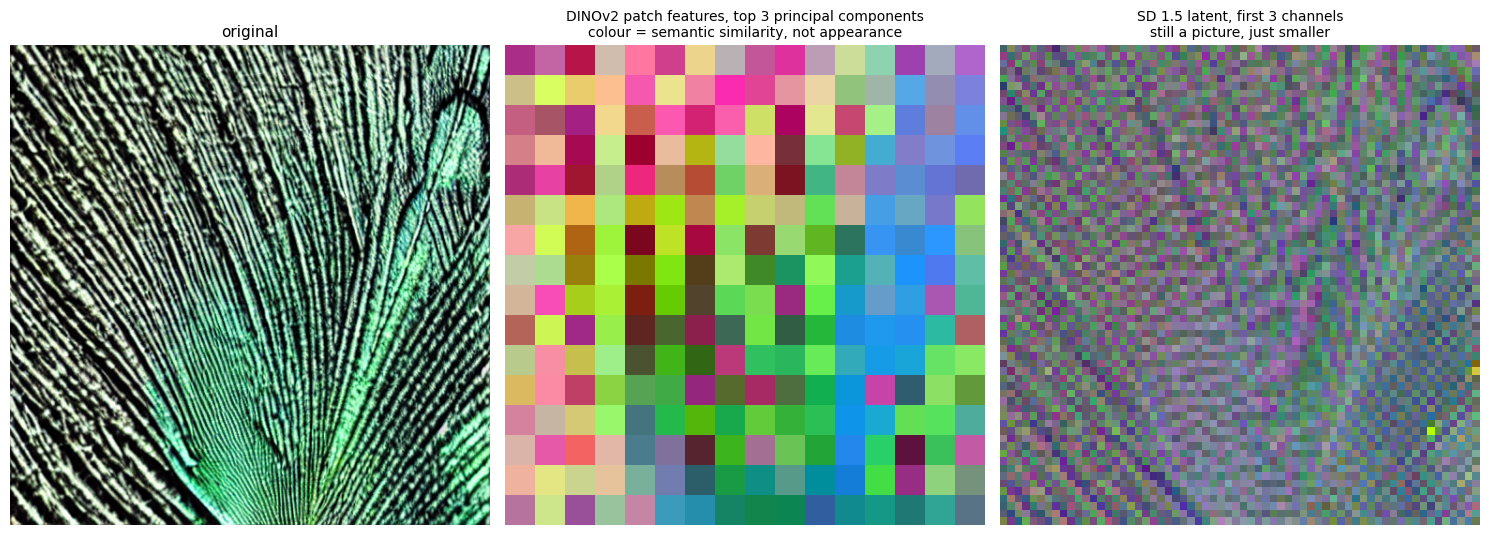

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))

axes[0].imshow(source); axes[0].set_title("original", fontsize=11)

axes[1].imshow(sem)
axes[1].set_title("DINOv2 patch features, top 3 principal components\n"
                  "colour = semantic similarity, not appearance", fontsize=10)

# The SD latent, for contrast: its channels still look like a blurry picture.
vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae",
                                    torch_dtype=torch.float32, local_files_only=True).to(DEV).eval()
x = torch.from_numpy(np.array(source)).float() / 127.5 - 1.0
with torch.no_grad():
    lat = vae.encode(x.permute(2, 0, 1).unsqueeze(0).to(DEV)).latent_dist.mean
l = lat[0, :3].float().cpu().numpy().transpose(1, 2, 0)
l = (l - l.min()) / (np.ptp(l) + 1e-6)
axes[2].imshow(l)
axes[2].set_title("SD 1.5 latent, first 3 channels\nstill a picture, just smaller", fontsize=10)

for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
del vae; torch.cuda.empty_cache()

This is the difference the whole argument rests on.

The Stable Diffusion latent still looks like the image. It is a compressed picture, and you can
almost read it. Regions with the same colour in the original have the same colour in the latent.

The DINOv2 projection does not look like the image. Regions share a colour when they are *the same
kind of thing*, regardless of how they appear. That is a semantic organisation, and it is what
representation autoencoders propose to generate inside.

It also shows the cost immediately. There is no way to recover the original pixels from that middle
panel by inspection, because the fine texture is simply not represented. A representation
autoencoder has to train a decoder to hallucinate it back, which is exactly the weakness the
[hybrid line](/lines/line-latent-hybrid) exists to patch.

## What to take away

- Every latent has a reconstruction ceiling, and it binds. Moving from 4 to 16 channels was the
  field raising that ceiling, and it worked.
- The loss is concentrated in edges and fine texture, which is why editing is harder than generation.
- A foundation model's features are not a better compression. They are organised by meaning rather
  than appearance, which is what makes them attractive to generate in and what makes them lossy in a
  way no channel count fixes.

The [comparison page](/compare) explains why the published FID numbers cannot settle which of these
is better, and the [representation-latent line](/lines/line-representation-latent) traces the
argument in full.